# Laboratorio 05 - Clasificación multiclase

**Nombre del alumno**: Nisse Maximiliano Martinez Pardo \
**Link a github del laboratorio**: https://github.com/nmmartinezp/SIS420-Inteligencia-Artifical---NMMP/tree/master/Laboratorios/Laboratorio%2005 \
**Link de dataset**: https://www.kaggle.com/datasets/stanfordu/street-view-house-numbers/data

## Contexto del dataset

Este conjunto de datos contiene tres archivos .zip con más de 600 000 imágenes reales etiquetadas de números de casas, obtenidas de Google Street View. La secuencia de números en las imágenes tiene una longitud limitada.

## Librerias usadas

In [1]:

import os
import numpy as np
from matplotlib import pyplot
import matplotlib.pyplot as plt
from scipy import optimize
import zipfile
import tempfile
import shutil
import warnings
warnings.filterwarnings('ignore')

from PIL import Image
import h5py

%matplotlib inline


## Montar Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Funciones para Cargar los datos del dataset - Street View House Numbers (SVHN)

In [3]:
def cargar_digitStruct_h5py(ruta_mat):

    print(f"  Cargando {os.path.basename(ruta_mat)}...")

    info_imagenes = {}

    with h5py.File(ruta_mat, 'r') as f:
        # Obtener la estructura principal
        digitStruct = f['digitStruct']

        # Obtener nombres y bboxes
        names = digitStruct['name']
        bboxes = digitStruct['bbox']

        total = len(names)
        print(f"    Procesando {total} imágenes...")

        for i in range(total):
            # OBTENER NOMBRE
            # El nombre es una referencia
            ref_name = names[i][0]
            # Obtener el objeto referenciado
            name_data = f[ref_name]
            # Convertir a string
            nombre = ''.join(chr(c[0]) for c in name_data)
            # Limpiar
            nombre = nombre.strip()
            if not nombre.endswith('.png'):
                nombre = nombre + '.png'

            # OBTENER BBOX
            ref_bbox = bboxes[i][0]
            bbox_data = f[ref_bbox]

            # Obtener todos los campos
            heights = bbox_data['height']
            widths = bbox_data['width']
            lefts = bbox_data['left']
            tops = bbox_data['top']
            labels = bbox_data['label']

            num_bboxes = len(heights)
            bbox_list = []

            for j in range(num_bboxes):
                try:
                    # Obtener cada valor - manejando referencias
                    h_ref = heights[j][0]
                    w_ref = widths[j][0]
                    l_ref = lefts[j][0]
                    t_ref = tops[j][0]
                    lab_ref = labels[j][0]

                    # Si son referencias, obtener el valor
                    if isinstance(h_ref, h5py.h5r.Reference):
                        h = float(f[h_ref][0][0])
                        w = float(f[w_ref][0][0])
                        l = float(f[l_ref][0][0])
                        t = float(f[t_ref][0][0])
                        lab = int(f[lab_ref][0][0])
                    else:
                        h = float(h_ref)
                        w = float(w_ref)
                        l = float(l_ref)
                        t = float(t_ref)
                        lab = int(lab_ref)

                    # SVHN: 10 = 0
                    if lab == 10:
                        lab = 0

                    bbox_list.append({
                        'height': h, 'width': w,
                        'left': l, 'top': t,
                        'label': lab
                    })
                except:
                    continue

            if bbox_list:
                info_imagenes[nombre] = bbox_list

            if (i + 1) % 10000 == 0:
                print(f"    Procesadas {i+1}/{total} imágenes...")

    print(f"    ✅ Cargadas {len(info_imagenes)} imágenes")
    total_digitos = sum(len(v) for v in info_imagenes.values())
    print(f"    ✅ Total de dígitos: {total_digitos}")

    return info_imagenes


def extraer_digitos_imagen(ruta_imagen, bboxes, tamaño=(32, 32)):

    try:
        img = Image.open(ruta_imagen).convert('RGB')
        digitos, labels = [], []

        for bbox in bboxes:
            left = max(0, int(bbox['left']))
            top = max(0, int(bbox['top']))
            right = min(img.width, left + int(bbox['width']))
            bottom = min(img.height, top + int(bbox['height']))

            if right > left and bottom > top:
                digit = img.crop((left, top, right, bottom))
                digit = digit.resize(tamaño, Image.Resampling.LANCZOS)
                digit_array = np.array(digit, dtype=np.float32) / 255.0
                digitos.append(digit_array)
                labels.append(bbox['label'])

        return digitos, labels
    except:
        return [], []


def cargar_svhn(ruta_zip, num_train=500, num_test=100):

    print("=" * 60)
    print("CARGANDO SVHN")
    print("=" * 60)

    temp_dir = tempfile.mkdtemp()

    try:
        # Extraer
        print(f"\nExtrayendo...")
        with zipfile.ZipFile(ruta_zip, 'r') as z:
            z.extractall(temp_dir)

        # Buscar archivos
        mat_files = []
        dirs_png = []

        for root, dirs, files in os.walk(temp_dir):
            for f in files:
                if f.endswith('.mat'):
                    mat_files.append(os.path.join(root, f))
            if any(f.endswith('.png') for f in files):
                dirs_png.append(root)

        print(f"\nArchivos .mat: {[os.path.basename(f) for f in mat_files]}")
        print(f"Directorios con PNG: {[os.path.basename(d) for d in dirs_png]}")

        # Identificar train y test
        mat_train = None
        mat_test = None
        dir_train = None
        dir_test = None

        for f in mat_files:
            name = os.path.basename(f).lower()
            if 'train' in name:
                mat_train = f
            elif 'test' in name:
                mat_test = f

        for d in dirs_png:
            name = os.path.basename(d).lower()
            if 'train' in name:
                dir_train = d
            elif 'test' in name:
                dir_test = d

        # Si no se encuentra test, usar el segundo directorio
        if dir_test is None and len(dirs_png) > 1:
            dirs_png_sorted = sorted(dirs_png, key=lambda d: len(os.listdir(d)), reverse=True)
            dir_train = dirs_png_sorted[0]
            dir_test = dirs_png_sorted[1]

        # Cargar información de bounding boxes
        info_train = cargar_digitStruct_h5py(mat_train) if mat_train else {}
        info_test = cargar_digitStruct_h5py(mat_test) if mat_test else {}

        # Procesar imágenes
        def procesar(directorio, info, max_img, nombre):
            X, y = [], []
            archivos = []

            for root, _, files in os.walk(directorio):
                for f in files:
                    if f.endswith('.png'):
                        archivos.append(os.path.join(root, f))

            archivos = sorted(archivos)
            if max_img and max_img < len(archivos):
                np.random.seed(42)
                idx = np.random.choice(len(archivos), max_img, replace=False)
                archivos = [archivos[i] for i in sorted(idx)]

            print(f"  {nombre} Procesando {len(archivos)} imágenes...")

            for i, arch in enumerate(archivos):
                nombre_arch = os.path.basename(arch)
                bboxes = info.get(nombre_arch, [])

                if bboxes:
                    digitos, labels = extraer_digitos_imagen(arch, bboxes)
                    for d, l in zip(digitos, labels):
                        X.append(d.flatten())
                        y.append(l)
                else:
                    # Fallback: usar nombre del archivo
                    try:
                        label = int(''.join(filter(str.isdigit, nombre_arch)))
                        if label == 10: label = 0
                        img = Image.open(arch).convert('RGB')
                        img = img.resize((32, 32), Image.Resampling.LANCZOS)
                        X.append(np.array(img, dtype=np.float32).flatten() / 255.0)
                        y.append(label)
                    except:
                        continue

                if (i+1) % 5000 == 0:
                    print(f"    {nombre} Procesadas {i+1}/{len(archivos)}...")

            if X:
                return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)
            return np.array([]), np.array([])

        # Procesar
        print(f"\nPROCESANDO ENTRENAMIENTO:")
        X_train, y_train = procesar(dir_train, info_train, num_train, "Train")

        print(f"\nPROCESANDO PRUEBA:")
        X_test, y_test = procesar(dir_test, info_test, num_test, "Test")

        # Parámetros
        input_layer_size = X_train.shape[1] if X_train.shape[0] > 0 else 3072
        num_labels = len(np.unique(np.concatenate([y_train, y_test]))) if X_train.shape[0] > 0 else 10

        print(f"\nRESUMEN:")
        print(f"  Train: {X_train.shape[0]} dígitos")
        print(f"  Test: {X_test.shape[0]} dígitos")
        print(f"  Clases: {num_labels}")

        return X_train, X_test, y_train, y_test, input_layer_size, num_labels

    finally:
        shutil.rmtree(temp_dir, ignore_errors=True)



## Funciones de clasificación

In [4]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -250, 250)))


def lrCostFunction(theta, X, y, lambda_):
    m = y.size
    h = sigmoid(X.dot(theta))
    temp = theta.copy()
    temp[0] = 0

    J = (1/m) * np.sum(-y*np.log(h+1e-15) - (1-y)*np.log(1-h+1e-15)) + \
        (lambda_/(2*m)) * np.sum(temp**2)

    grad = (1/m) * X.T.dot(h-y) + (lambda_/m) * temp
    return J, grad


def oneVsAll(X, y, num_labels, lambda_):
    m, n = X.shape
    all_theta = np.zeros((num_labels, n + 1))
    X = np.concatenate([np.ones((m, 1)), X], axis=1)

    print(f"\nEntrenando {num_labels} clasificadores...")

    for c in range(num_labels):
        initial_theta = np.zeros(n + 1)
        options = {'maxiter': 50, 'disp': False}

        res = optimize.minimize(
            lrCostFunction,
            initial_theta,
            (X, (y == c).astype(int), lambda_),
            jac=True,
            method='CG',
            options=options
        )
        all_theta[c] = res.x
        print(f"  Clase {c} completada ({c+1}/{num_labels})")

    return all_theta


def predictOneVsAll(all_theta, X):
    m = X.shape[0]
    X = np.concatenate([np.ones((m, 1)), X], axis=1)
    return np.argmax(sigmoid(X.dot(all_theta.T)), axis=1)


def displayData(X, figsize=(10, 10), max_muestras=100):
    if X.ndim != 2:
        return
    m = min(X.shape[0], max_muestras)
    X = X[:m]

    n = X.shape[1]
    ancho = int(np.sqrt(n/3))

    X_reshape = [X[i].reshape(ancho, ancho, 3) for i in range(m)]

    rows = int(np.floor(np.sqrt(m)))
    cols = int(np.ceil(m / rows))

    fig, axes = pyplot.subplots(rows, cols, figsize=figsize)
    fig.subplots_adjust(wspace=0.025, hspace=0.025)
    axes = axes.ravel() if rows > 1 else [axes]

    for i, ax in enumerate(axes):
        if i < m:
            ax.imshow(X_reshape[i])
        ax.axis('off')


def mostrar_predicciones(X, y_real, y_pred, n=10):
    n = min(n, X.shape[0])
    idx = np.random.choice(X.shape[0], n, replace=False)

    cols = 5
    rows = int(np.ceil(n/cols))
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3*rows))
    axes = axes.ravel()

    for i in range(n):
        img = X[idx[i]].reshape(32, 32, 3)
        axes[i].imshow(img)
        color = 'green' if y_pred[idx[i]] == y_real[idx[i]] else 'red'
        axes[i].set_title(f'Pred: {y_pred[idx[i]]} | Real: {y_real[idx[i]]}',
                         color=color, fontsize=10)
        axes[i].axis('off')

    for i in range(n, len(axes)):
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()


## Carga de datos

In [9]:
RUTA_ZIP = '/content/drive/MyDrive/Courses/SIS420 Inteligencia artidicial I/Datasets/street_view_house.zip'

# Configuración
NUM_TRAIN = 50000
NUM_TEST = 20000
LAMBDA = 0.1

# Cargar datos
X_train, X_test, y_train, y_test, input_size, num_labels = cargar_svhn(
    RUTA_ZIP, NUM_TRAIN, NUM_TEST
)

print(f"\nDatos cargados:")
print(f"  Train: {X_train.shape}")
print(f"  Test: {X_test.shape}")

CARGANDO SVHN

Extrayendo...

Archivos .mat: ['extra_digitStruct.mat', 'train_digitStruct.mat', 'test_digitStruct.mat']
Directorios con PNG: ['test', 'train', 'extra']
  Cargando train_digitStruct.mat...
    Procesando 33402 imágenes...
    Procesadas 10000/33402 imágenes...
    Procesadas 20000/33402 imágenes...
    Procesadas 30000/33402 imágenes...
    ✅ Cargadas 33402 imágenes
    ✅ Total de dígitos: 73257
  Cargando test_digitStruct.mat...
    Procesando 13068 imágenes...
    Procesadas 10000/13068 imágenes...
    ✅ Cargadas 13068 imágenes
    ✅ Total de dígitos: 26032

PROCESANDO ENTRENAMIENTO:
  Train Procesando 33402 imágenes...
    Train Procesadas 5000/33402...
    Train Procesadas 10000/33402...
    Train Procesadas 15000/33402...
    Train Procesadas 20000/33402...
    Train Procesadas 25000/33402...
    Train Procesadas 30000/33402...

PROCESANDO PRUEBA:
  Test Procesando 13068 imágenes...
    Test Procesadas 5000/13068...
    Test Procesadas 10000/13068...

RESUMEN:
  Tra

## Visualizar imagenes


Mostrando imágenes...


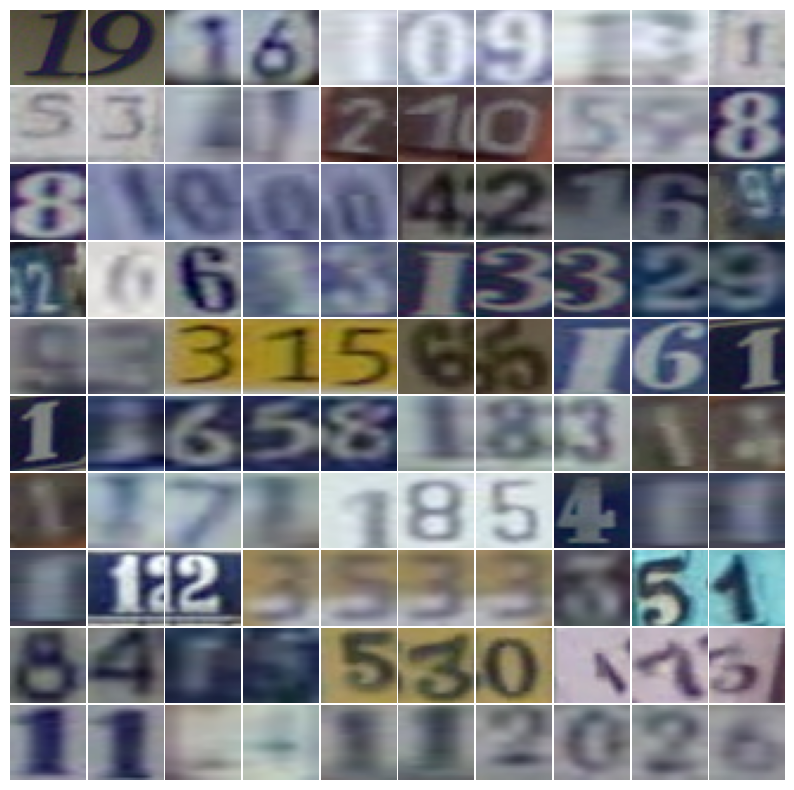

In [10]:
# Visualizar
print("\nMostrando imágenes...")
displayData(X_train, max_muestras=100)
plt.show()

## Uso de OneVsAll

In [11]:
# Entrenar
print("\nEntrenando...")
all_theta = oneVsAll(X_train, y_train, num_labels, LAMBDA)


Entrenando...

Entrenando 10 clasificadores...
  Clase 0 completada (1/10)
  Clase 1 completada (2/10)
  Clase 2 completada (3/10)
  Clase 3 completada (4/10)
  Clase 4 completada (5/10)
  Clase 5 completada (6/10)
  Clase 6 completada (7/10)
  Clase 7 completada (8/10)
  Clase 8 completada (9/10)
  Clase 9 completada (10/10)


## Uso de predictOneVsAll


Evaluando...
  Precisión Train: 28.43%
  Precisión Test: 24.17%

Predicciones:


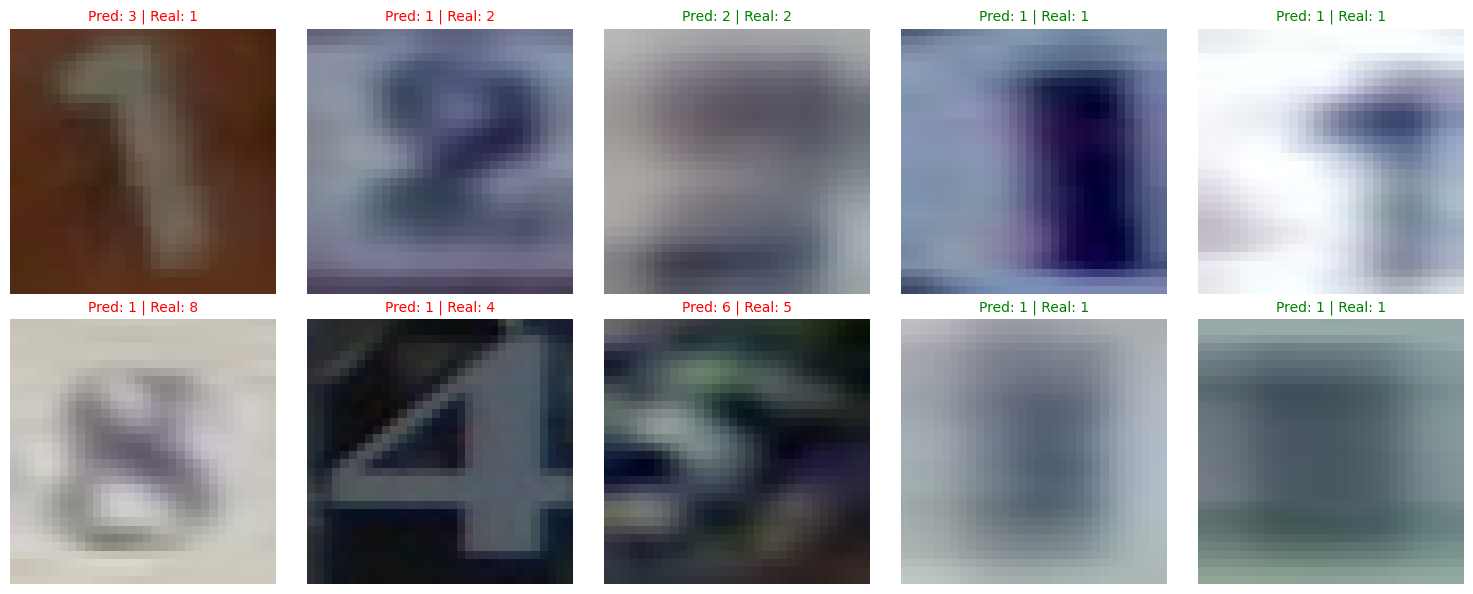

In [12]:
# Evaluar
print("\nEvaluando...")
pred_train = predictOneVsAll(all_theta, X_train)
pred_test = predictOneVsAll(all_theta, X_test)

print(f'  Precisión Train: {np.mean(pred_train == y_train)*100:.2f}%')
print(f'  Precisión Test: {np.mean(pred_test == y_test)*100:.2f}%')

# Mostrar predicciones
print("\nPredicciones:")
mostrar_predicciones(X_test, y_test, pred_test, n=10)